## 1.1 Tasks

In [1]:
import torch
import numpy as np

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [2]:
# Grid for computing image, subdivide the space
X, Y = np.mgrid[-4.0:4:0.01, -4.0:4:0.01]

# Load into PyTorch tensors
x = torch.Tensor(X)
y = torch.Tensor(Y)

# Transfer to the GPU device
x = x.to(device)
y = y.to(device)

In [3]:
# Compute Gaussian
z = torch.exp(-(x**2+y**2)/2.0)

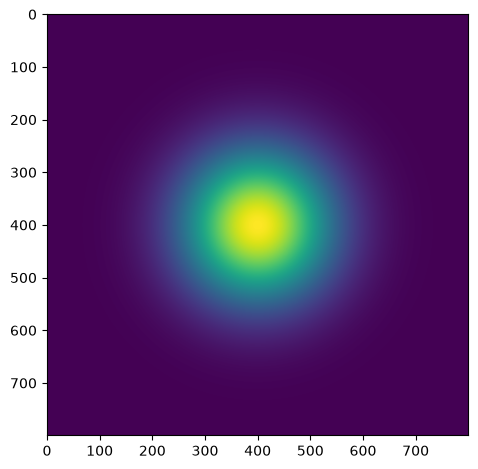

In [4]:
# Plot
import matplotlib.pyplot as plt

plt.imshow(z.cpu().numpy()) # Update!

plt.tight_layout()
plt.show()

## 1.2 AI Tasks

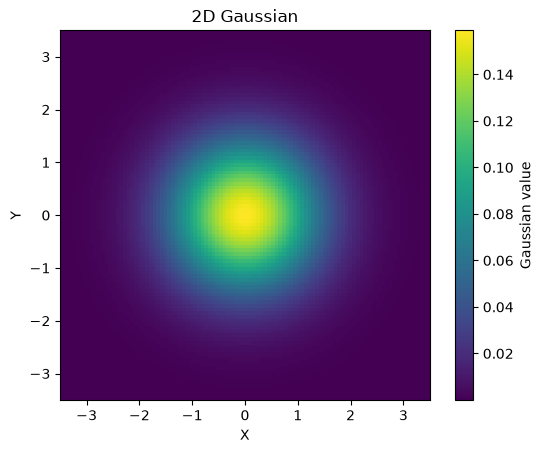

In [ ]:
# Prompt: "Generate a Python script to plot a 2D Gaussian function using Numpy and Matplotlib"
# Model: Gemini 3.1 Pro

import numpy as np
import matplotlib.pyplot as plt

# 1. Define Gaussian parameters
mu_x = 0.0
mu_y = 0.0
sigma_x = 1.0
sigma_y = 1.0

# 2. Create a 2D grid of X and Y coordinates
x = np.linspace(-3.5, 3.5, 100)
y = np.linspace(-3.5, 3.5, 100)

X, Y = np.meshgrid(x, y)

# 3. Calculate the 2D Gaussian
coefficient = 1 / (2 * np.pi * sigma_x * sigma_y)

exponential = np.exp(
    -(
        (X - mu_x)**2 / (2 * sigma_x**2)
        + (Y - mu_y)**2 / (2 * sigma_y**2)
    )
)

Z = coefficient * exponential

# 4. Plot as a 2D image
plt.imshow(
    Z,
    extent=[x.min(), x.max(), y.min(), y.max()],
    origin="lower"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("2D Gaussian")

plt.colorbar(label="Gaussian value")

plt.show()

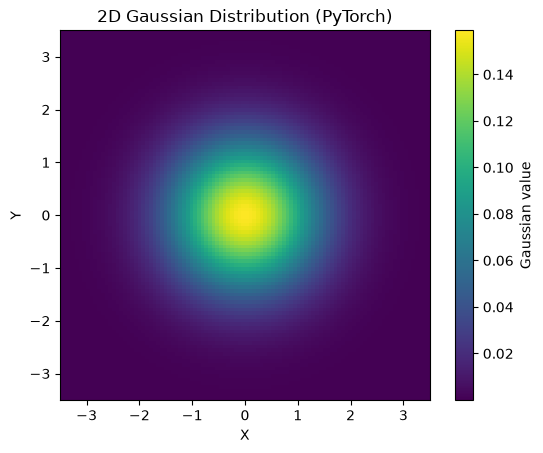

In [35]:
# Prompt: "Convert this script to PyTorch and to use its Tensors instead of Numpy."
# Model: Gemini 3.1 Pro

import torch
import matplotlib.pyplot as plt

# 1. Define the parameters for the Gaussian distribution
mu_x = 0.0
mu_y = 0.0
sigma_x = 1.0
sigma_y = 1.0

# 2. Create a 2D grid of X and Y coordinates using PyTorch tensors
x = torch.linspace(-3.5, 3.5, 100)
y = torch.linspace(-3.5, 3.5, 100)

X, Y = torch.meshgrid(x, y, indexing='xy')

# 3. Calculate the 2D Gaussian
coefficient = 1 / (2 * torch.pi * sigma_x * sigma_y)

exponential = torch.exp(
    -(
        (X - mu_x)**2 / (2 * sigma_x**2)
        + (Y - mu_y)**2 / (2 * sigma_y**2)
    )
)

Z = coefficient * exponential

# 4. Plot as a 2D image
plt.imshow(
    Z.numpy(),
    extent=[x.min(), x.max(), y.min(), y.max()],
    origin="lower"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("2D Gaussian Distribution (PyTorch)")

plt.colorbar(label="Gaussian value")

plt.show()

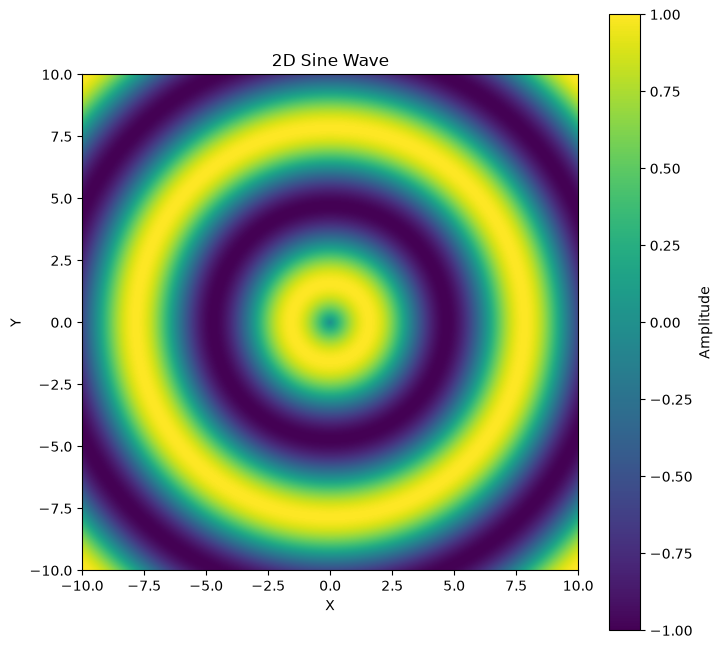

In [36]:
# Prompt: "Generate a Python script to plot a  a sine function from PyTorch whose angle is dependent on x and y coordinates of the pixels."
# Model: Gemini 3.1 Pro

import torch
import matplotlib.pyplot as plt

# 1. Create a high-resolution 2D grid of X and Y coordinates
x = torch.linspace(-10.0, 10.0, 500)
y = torch.linspace(-10.0, 10.0, 500)

X, Y = torch.meshgrid(x, y, indexing='xy')

# 2. Define the angle from the distance to the origin
angle = torch.sqrt(X**2 + Y**2)

# 3. Apply the sine function
Z = torch.sin(angle)

# 4. Plot as a 2D image
plt.figure(figsize=(8, 8))

plt.imshow(
    Z.numpy(),
    extent=[x.min(), x.max(), y.min(), y.max()],
    origin="lower"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("2D Sine Wave")

plt.colorbar(label="Amplitude")

plt.show()

## 1.3 Demonstration

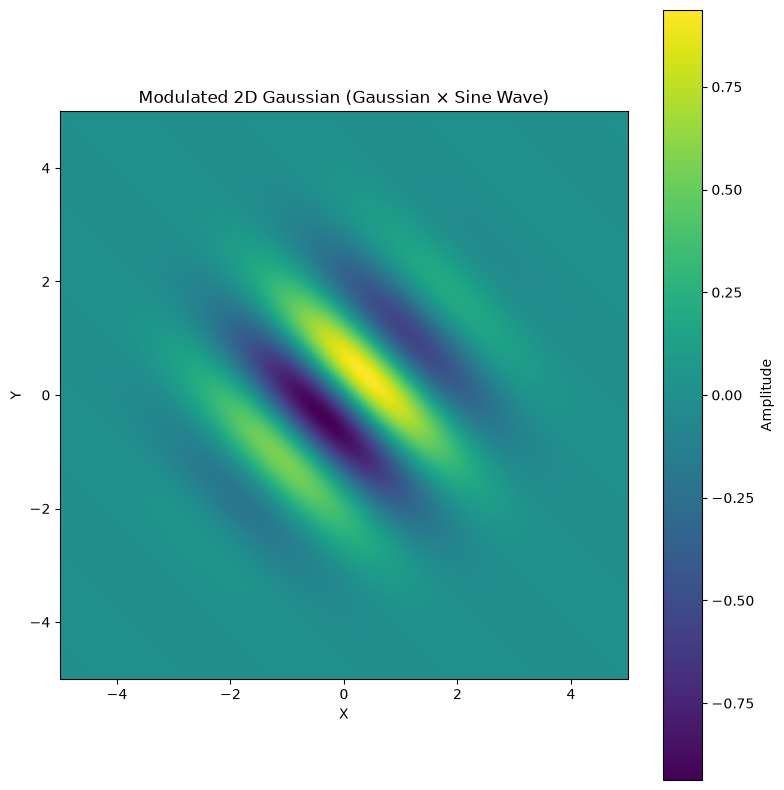

In [37]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Create 2D grid
x = torch.linspace(-5.0, 5.0, 300)
y = torch.linspace(-5.0, 5.0, 300)
X, Y = torch.meshgrid(x, y, indexing='xy')

# Gaussian function parameters
sigma_x, sigma_y = 1.5, 1.5

gaussian = torch.exp(
    -(X**2 / (2 * sigma_x**2) + Y**2 / (2 * sigma_y**2))
)

# Sine stripe pattern dependent on X and Y coordinates
frequency = 2.0
sine_wave = torch.sin(frequency * (X + Y))

# Modulated Gaussian / Gabor-like pattern
Z = gaussian * sine_wave

# Plot as a 2D image
plt.figure(figsize=(8, 8))

plt.imshow(
    Z.numpy(),
    extent=[x.min(), x.max(), y.min(), y.max()],
    origin="lower"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Modulated 2D Gaussian (Gaussian × Sine Wave)")

plt.colorbar(label="Amplitude")

plt.tight_layout()
plt.show()

## 2.1 Tasks

In [9]:
import torch
import numpy as np

In [10]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [11]:
# Use NumPy to create a 2D array of complex numbers on [-2,2]x[-2,2]
Y, X = np.mgrid[-1.3:1.3:0.005, -2:1:0.005]

In [12]:
# load into PyTorch tensors
x = torch.Tensor(X)
y = torch.Tensor(Y)
z = torch.complex(x,y) #important!
zs = z.clone() #Updated!
ns = torch.zeros_like(zs.real, dtype=torch.int32) 

In [13]:
# transfer to the GPU device
z = z.to(device)
zs = zs.to(device)
ns = ns.to(device)

In [14]:
# Mandelbrot Set
for i in range(200):
  # Compute the new values of z: z^2 + x
  zs_ = zs*zs + z
  # Have we diverged with this new value?
  not_diverged = torch.abs(zs_) < 4.0
  # Update variables to compute
  ns += not_diverged
  zs = zs_

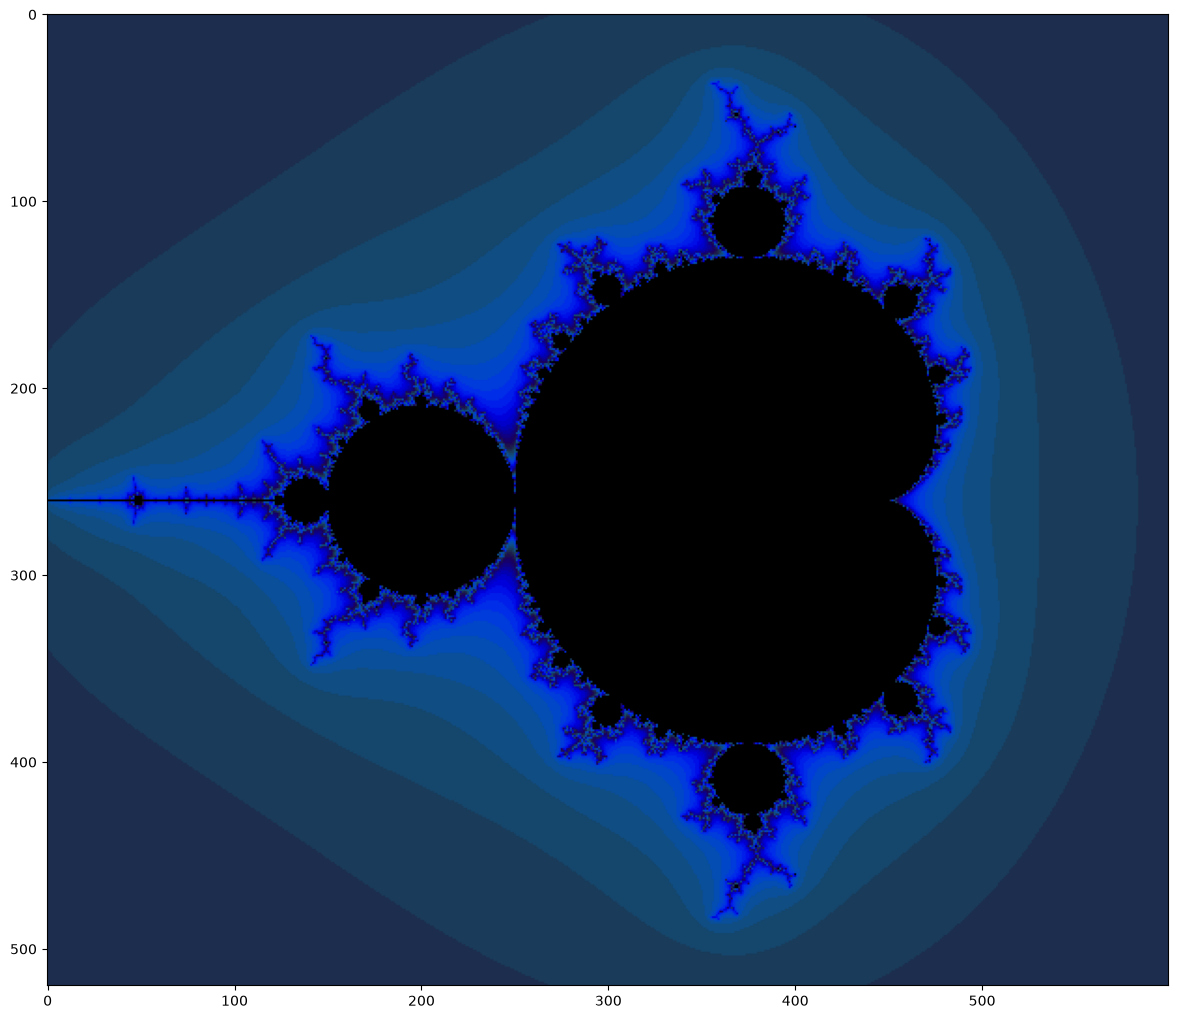

In [15]:
#plot
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16,10))

def processFractal(a):
  """Display an array of iteration counts as a colorful picture of a fractal."""
  a_cyclic = (6.28*a/20.0).reshape(list(a.shape)+[1])
  img = np.concatenate([10+20*np.cos(a_cyclic),
                        30+50*np.sin(a_cyclic),
                        155-80*np.cos(a_cyclic)], 2)
  img[a==a.max()] = 0
  a = img
  a = np.uint8(np.clip(a, 0, 255))
  return a

plt.imshow(processFractal(ns.cpu().numpy()))
plt.tight_layout(pad=0)
plt.show()


## 2.2 AI Tasks

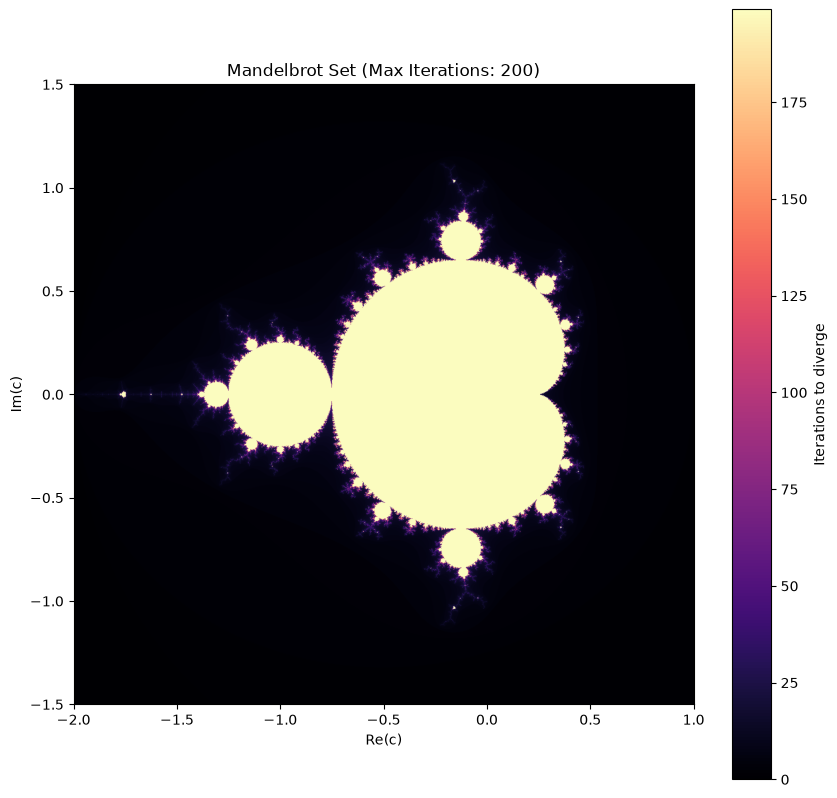

In [16]:
'''Prompt: "Generate a Python script using PyTorch and CUDA to compute
and plot the Mandelbrot set on a complex plane grid over 200 iterations, then display the resulting divergence map with Matplotlib.'''
# Model: Gemini 3.1 Pro

import torch
import matplotlib.pyplot as plt

def compute_mandelbrot(h, w, max_iters=200):
    # Initialize the device to CUDA if available, otherwise fallback to CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Define the complex plane boundaries
    # Standard Mandelbrot range: Real [-2.0, 1.0], Imaginary [-1.5, 1.5]
    y, x = torch.meshgrid(
        torch.linspace(-1.5, 1.5, h, device=device),
        torch.linspace(-2.0, 1.0, w, device=device),
        indexing='ij'
    )
    # Combine X and Y into a complex grid: c = x + iy
    c = x + 1j * y

    # Initialize z to 0 and the divergence map to store iteration counts
    z = torch.zeros_like(c)
    div_map = torch.zeros(c.shape, dtype=torch.int32, device=device)

    # Compute iterations
    for i in range(max_iters):
        # Mask points that haven't escaped the radius of 2
        mask = torch.abs(z) <= 2.0

        # Apply the Mandelbrot function only to the non-diverged points
        z[mask] = z[mask]**2 + c[mask]

        # Update the iteration count for points that are still bounded
        div_map[mask] = i

    # Move the resulting tensor back to the CPU for plotting with Matplotlib
    return div_map.cpu()

# Configuration parameters
width, height = 1200, 1200
iterations = 200

# Compute the divergence map
divergence_map = compute_mandelbrot(height, width, iterations)

# Plot the result using Matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(divergence_map, cmap='magma', extent=[-2.0, 1.0, -1.5, 1.5])
plt.colorbar(label='Iterations to diverge')
plt.title(f'Mandelbrot Set (Max Iterations: {iterations})')
plt.xlabel('Re(c)')
plt.ylabel('Im(c)')
plt.show()

The AI-generated PyTorch implementation worked as intended without requiring code modifications. It successfully used tensor operations and ran on the selected GPU device. I still verified the output visually and checked that the tensors were moved to CUDA correctly.

## 2.3 Demonstration




### High-Res Plot

In [17]:
# High-resolution zoomed-in grid
# Less step size and spacing
Y, X = np.mgrid[
    0.60:0.90:0.0002,
    -0.3:0.1:0.0002
]

In [18]:
# load into PyTorch tensors
x = torch.Tensor(X)
y = torch.Tensor(Y)
z = torch.complex(x,y) #important!
zs = z.clone() #Updated!
ns = torch.zeros_like(zs.real, dtype=torch.int32)


In [19]:
# transfer to the GPU device
z = z.to(device)
zs = zs.to(device)
ns = ns.to(device)

In [20]:
# Mandelbrot Set
for i in range(200):
  # Compute the new values of z: z^2 + x
  zs_ = zs*zs + z
  # Have we diverged with this new value?
  not_diverged = torch.abs(zs_) < 4.0
  # Update variables to compute
  ns += not_diverged
  zs = zs_

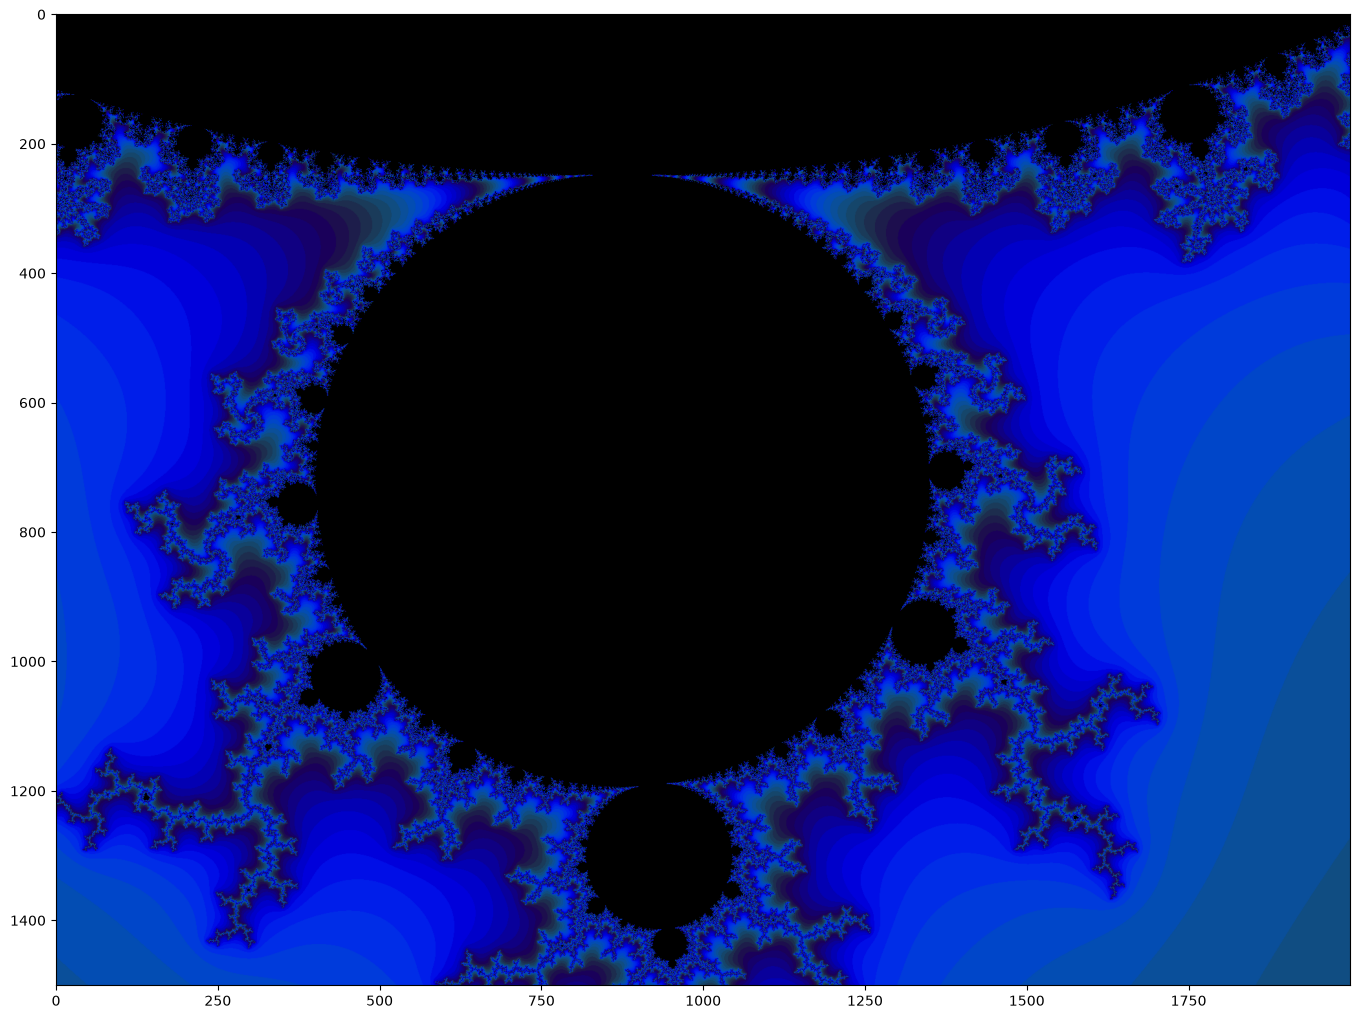

In [21]:
#plot
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16,10))

def processFractal(a):
  """Display an array of iteration counts as a colorful picture of a fractal."""
  a_cyclic = (6.28*a/20.0).reshape(list(a.shape)+[1])
  img = np.concatenate([10+20*np.cos(a_cyclic),
                        30+50*np.sin(a_cyclic),
                        155-80*np.cos(a_cyclic)], 2)
  img[a==a.max()] = 0
  a = img
  a = np.uint8(np.clip(a, 0, 255))
  return a

plt.imshow(processFractal(ns.cpu().numpy()))
plt.tight_layout(pad=0)
plt.show()


### Julia Set

In [22]:
# Use NumPy to create a 2D array of complex numbers on [-2,2]x[-2,2]
Y, X = np.mgrid[-1.3:1.3:0.005, -2:2:0.005]

In [23]:
# load into PyTorch tensors
x = torch.Tensor(X)
y = torch.Tensor(Y)
zs = torch.complex(x,y) # zs represents every starting point on the complex grid
ns = torch.zeros_like(zs.real, dtype=torch.int32) 
c = torch.tensor(-0.7 + 0.27015j) # c is a single fixed complex number chosen

In [24]:
# transfer to the GPU device
zs = zs.to(device)
ns = ns.to(device)
c = c.to(device)

In [25]:
# Julia Set
for i in range(200):
  # Compute the new values of z: z^2 + c
  # Adding fixed constant 'c'
  zs_ = zs*zs + c
  # Have we diverged with this new value?
  not_diverged = torch.abs(zs_) < 4.0
  # Update variables to compute
  ns += not_diverged
  zs = zs_

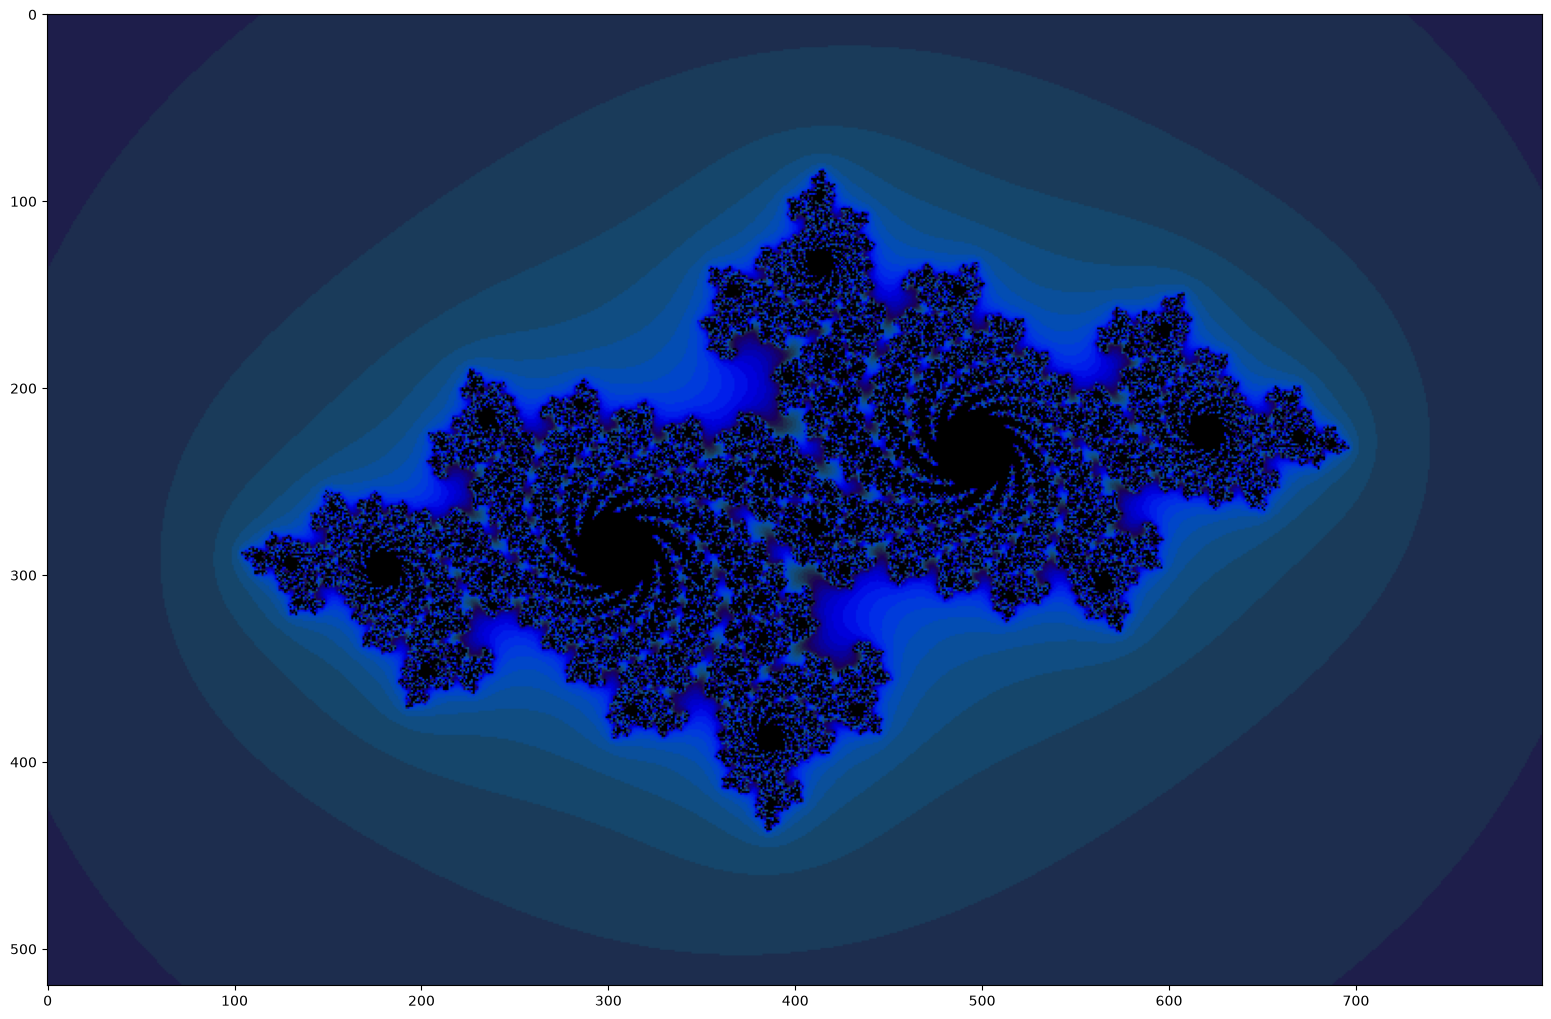

In [26]:
#plot
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16,10))

def processFractal(a):
  """Display an array of iteration counts as a colorful picture of a fractal."""
  a_cyclic = (6.28*a/20.0).reshape(list(a.shape)+[1])
  img = np.concatenate([10+20*np.cos(a_cyclic),
                        30+50*np.sin(a_cyclic),
                        155-80*np.cos(a_cyclic)], 2)
  img[a==a.max()] = 0
  a = img
  a = np.uint8(np.clip(a, 0, 255))
  return a

plt.imshow(processFractal(ns.cpu().numpy()))
plt.tight_layout(pad=0)
plt.show()


## 3.3 Tasks

#### AI Documentation
https://chatgpt.com/share/6a84e7bb-0c10-83ec-8b35-475479b05af8

#### Implementation Flow
1. Choose depth n
2. Compute image size N = 3^n
3. Create the x and y coordinate tensors on the GPU
4. Create an initially-full Boolean carpet mask
5. Find pixels where both coordinates are in the middle third using modulo 3
6. Remove those pixels from the mask
7. Integer-divide both coordinate tensors by 3
8. Repeat steps 5–7 for n levels
9. Transfer the final mask to the CPU
10. Plot it as an image

### Sierpinski Carpet Algorithm

In [27]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def generate_carpet(n, device):
    N = 3**n # Size of the grid (3^n x 3^n)

    x_work = torch.arange(N, device=device, dtype=torch.int32).unsqueeze(0) # Row vector of x-coordinates
    y_work = torch.arange(N, device=device, dtype=torch.int32).unsqueeze(1) # Column vector of y-coordinates

    mask = torch.ones((N, N), dtype=torch.bool, device=device) # True represents pixels that currently belong to the carpet

    for _ in range(n):
        mask &= ~((x_work % 3 == 1) & (y_work % 3 == 1)) # Remove pixels lying in the centre third of both coordinates at the current fractal scale
        x_work //= 3 # Move to next fractal scale   
        y_work //= 3

    return mask
    

 `x_work` and `y_work` have shapes (1,N) and (N,1). PyTorch broadcasting combines these conditions across all row/column combinations, producing an (N,N) mask without looping over individual pixels.

### Plots with varying depths

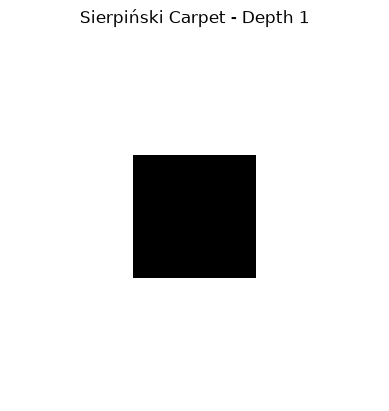

Depth 1: Remaining points = 8, Total points = 9, Ratio = 0.8889, Expected = 8


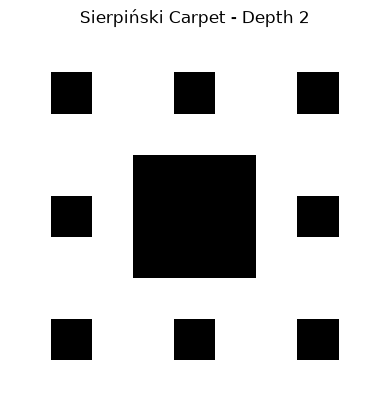

Depth 2: Remaining points = 64, Total points = 81, Ratio = 0.7901, Expected = 64


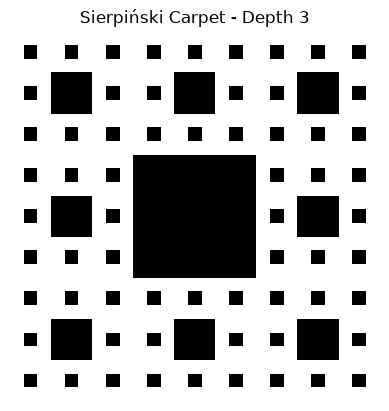

Depth 3: Remaining points = 512, Total points = 729, Ratio = 0.7023, Expected = 512


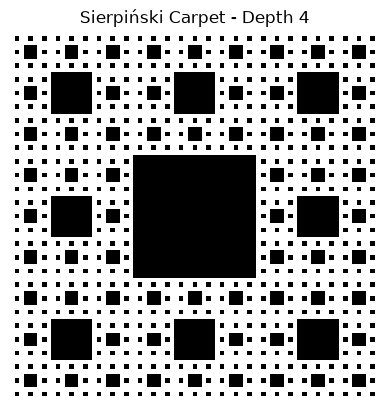

Depth 4: Remaining points = 4096, Total points = 6561, Ratio = 0.6243, Expected = 4096


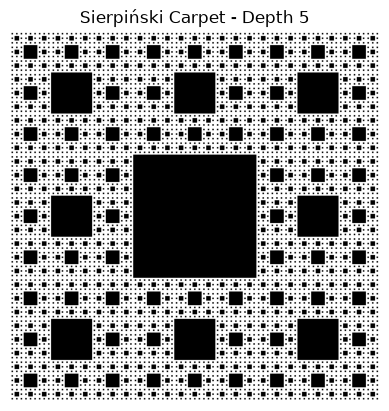

Depth 5: Remaining points = 32768, Total points = 59049, Ratio = 0.5549, Expected = 32768


In [28]:
depths = [1, 2, 3, 4, 5]

for n in depths:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    mask = generate_carpet(n, device)

    plt.figure()
    plt.imshow(mask.cpu(), cmap="gray")
    plt.title(f"Sierpiński Carpet - Depth {n}")
    plt.axis("off")
    plt.show()

    remaining = mask.sum().item()
    expected = 8**n
    print(f"Depth {n}: Remaining points = {remaining}, Total points = {3**(2*n)}, Ratio = {remaining / (3**(2*n)):.4f}, Expected = {expected}")

### Box Counting Algorithm

In [29]:
def count_boxes(mask, box_size):
    height, width = mask.shape

    if height != width:
        raise ValueError("mask must be square")

    if height % box_size != 0:
        raise ValueError(
            f"box_size ({box_size}) must evenly divide mask size ({height})"
        )

    reshaped = mask.reshape(
        height // box_size,
        box_size,
        width // box_size,
        box_size
    )

    occupied = reshaped.any(dim=(1, 3))

    return occupied.sum().item()

Box size: 243, Occupied boxes: 8
Box size:  81, Occupied boxes: 64
Box size:  27, Occupied boxes: 512
Box size:   9, Occupied boxes: 4096
Box size:   3, Occupied boxes: 32768
Box size:   1, Occupied boxes: 262144


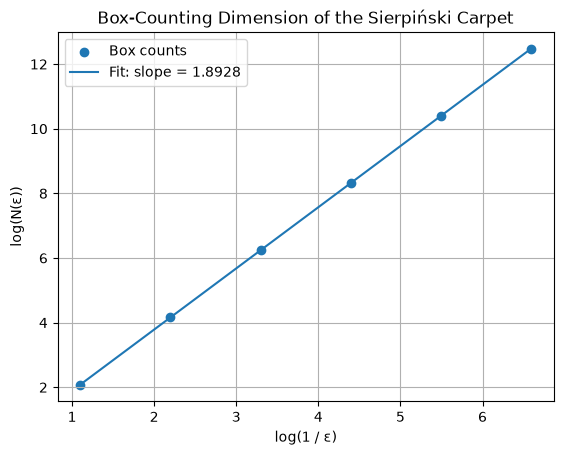

Estimated fractal dimension: 1.892789
Theoretical fractal dimension: 1.892789


In [30]:
n = 6 # Fractal depth

mask = generate_carpet(n, device)

N = mask.shape[0] # Size of the grid (3^n x 3^n)

box_sizes = [243, 81, 27, 9, 3, 1]

counts = []

for size in box_sizes:
    count = count_boxes(mask, size)
    counts.append(count)

# Relative box size: epsilon = box_size / N
epsilon = np.array(box_sizes) / N

# x-axis for box-counting dimension
x = np.log(1 / epsilon)
y = np.log(counts)

for size, count in zip(box_sizes, counts):
    print(f"Box size: {size:3d}, Occupied boxes: {count}")

coefficients = np.polyfit(x, y, 1)

slope = coefficients[0]
intercept = coefficients[1]

y_fit = slope * x + intercept

plt.scatter(x, y, label="Box counts")
plt.plot(x, y_fit, label=f"Fit: slope = {slope:.4f}")

plt.xlabel("log(1 / ε)")
plt.ylabel("log(N(ε))")
plt.title("Box-Counting Dimension of the Sierpiński Carpet")

plt.legend()
plt.grid()
plt.show()

print(f"Estimated fractal dimension: {slope:.6f}")
print(f"Theoretical fractal dimension: {np.log(8) / np.log(3):.6f}")

### Theoretical vs Estimated Dimension

In [31]:
theoretical_dimension = np.log(8) / np.log(3)

slope, intercept = np.polyfit(x, y, 1)

# Predicted values from fitted line
y_pred = slope * x + intercept

# Absolute error in fractal dimension
absolute_error = abs(slope - theoretical_dimension)

# R^2 calculation
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)

r_squared = 1 - (ss_res / ss_tot)

print(f"Estimated dimension:   {slope:.10f}")
print(f"Theoretical dimension: {theoretical_dimension:.10f}")
print(f"Absolute error:         {absolute_error:.2e}")
print(f"R²:                     {r_squared:.10f}")

Estimated dimension:   1.8927892607
Theoretical dimension: 1.8927892607
Absolute error:         6.66e-16
R²:                     1.0000000000


“The estimated dimension is approximately 1.8928, which closely matches the theoretical value log(8)/log(3). The absolute error is nearly zero and the R
2
 value is nearly 1. This near-perfect agreement is expected because I deliberately chose box sizes that are powers of 3, which align exactly with the Sierpiński carpet’s recursive structure. So this experiment mainly validates that my implementation is behaving correctly.”

### CPU vs GPU

In [32]:
import time
import numpy as np
import matplotlib.pyplot as plt
import torch

depths = [1, 3, 5, 7, 8]
repeats = 10
warmup_runs = 3

mean_cpu_times = []
mean_gpu_times = []
speedups = []

# CUDA warm-up
if torch.cuda.is_available():
    gpu = torch.device("cuda")

    for _ in range(warmup_runs):
        _ = generate_carpet(5, gpu)

    torch.cuda.synchronize()

# Benchmark
for n in depths:
    cpu_times = []
    gpu_times = []

    for _ in range(repeats):

        # CPU
        start_cpu = time.perf_counter()
        mask_cpu = generate_carpet(n, torch.device("cpu"))
        end_cpu = time.perf_counter()

        cpu_times.append(end_cpu - start_cpu)

        # GPU
        if torch.cuda.is_available():
            gpu = torch.device("cuda")

            torch.cuda.synchronize()
            start_gpu = time.perf_counter()

            mask_gpu = generate_carpet(n, gpu)

            torch.cuda.synchronize()
            end_gpu = time.perf_counter()

            gpu_times.append(end_gpu - start_gpu)

    mean_cpu = np.mean(cpu_times)
    mean_cpu_times.append(mean_cpu)

    print(f"\nDepth {n}")
    print(f"Mean CPU time: {mean_cpu:.6f} seconds")

    if torch.cuda.is_available():
        mean_gpu = np.mean(gpu_times)
        mean_gpu_times.append(mean_gpu)

        speedup = mean_cpu / mean_gpu
        speedups.append(speedup)

        print(f"Mean GPU time: {mean_gpu:.6f} seconds")
        print(f"Speedup (CPU/GPU): {speedup:.2f}x")


Depth 1
Mean CPU time: 0.000288 seconds
Mean GPU time: 0.000193 seconds
Speedup (CPU/GPU): 1.49x

Depth 3
Mean CPU time: 0.000200 seconds
Mean GPU time: 0.000452 seconds
Speedup (CPU/GPU): 0.44x

Depth 5
Mean CPU time: 0.001675 seconds
Mean GPU time: 0.002120 seconds
Speedup (CPU/GPU): 0.79x

Depth 7
Mean CPU time: 0.012727 seconds
Mean GPU time: 0.002770 seconds
Speedup (CPU/GPU): 4.59x

Depth 8
Mean CPU time: 0.142134 seconds
Mean GPU time: 0.017339 seconds
Speedup (CPU/GPU): 8.20x


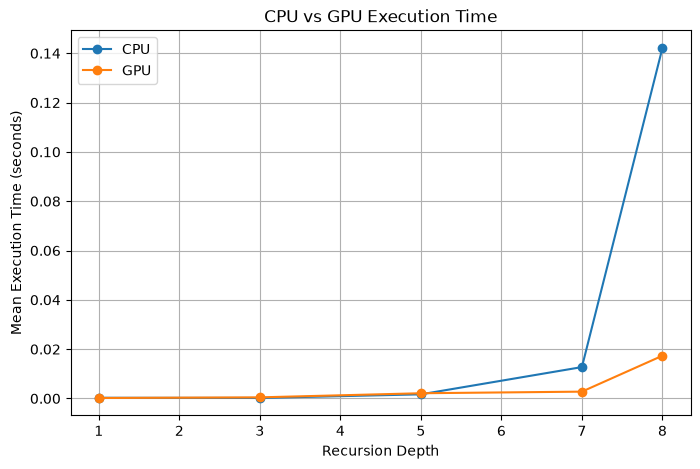

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(depths, mean_cpu_times, marker="o", label="CPU")

if torch.cuda.is_available():
    plt.plot(depths, mean_gpu_times, marker="o", label="GPU")

plt.xlabel("Recursion Depth")
plt.ylabel("Mean Execution Time (seconds)")
plt.title("CPU vs GPU Execution Time")
plt.legend()
plt.grid()

plt.show()

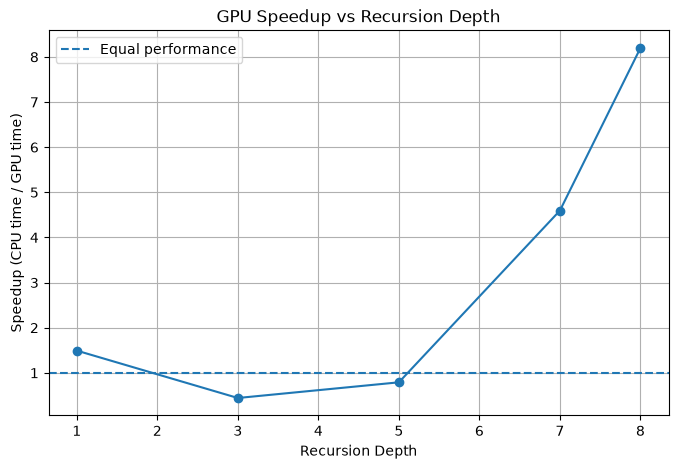

In [34]:
if torch.cuda.is_available():
    plt.figure(figsize=(8, 5))

    plt.plot(depths, speedups, marker="o")

    # Speedup = 1 means CPU and GPU are equally fast
    plt.axhline(y=1, linestyle="--", label="Equal performance")

    plt.xlabel("Recursion Depth")
    plt.ylabel("Speedup (CPU time / GPU time)")
    plt.title("GPU Speedup vs Recursion Depth")
    plt.legend()
    plt.grid()

    plt.show()

### Conclusion

• Tensor broadcasting allowed the carpet to be generated without
  pixel-by-pixel Python loops.

• The number of occupied pixels follows 8^n.

• Box counting produced an estimated dimension of approximately 1.8928,
  matching log(8)/log(3).

• CPU execution was faster for small problem sizes because GPU execution has kernel-launch and synchronization overhead. As the tensor size increased, the parallel workload became large enough to utilise the GPU      effectively, reaching approximately around 7× speedup at depth 9. 